In [5]:
import sys
!{sys.executable} -m pip install yfinance lightgbm optuna statsmodels scikit-learn matplotlib joblib

Baixando dados reais de ^BVSP até 2026-04-01...
Baixando dados macro (IBOV e Dólar)...

Dados separados! Treino: 2268 dias | Teste: 567 dias.
Otimizando hiperparâmetros do modelo (Isso leva alguns segundos)...

RESULTADO DO BACKTEST (Set de Teste)
  RMSE LightGBM : 0.02429 (Previsão via Delta)
  RMSE Baseline : 0.02301 (Média Móvel)
  MAPE          : 13.66%

INICIANDO COMPETIÇÃO DE MODELOS (BENCHMARKING)
Treinando o modelo GARCH(1,1) (Isso pode levar alguns segundos)...

[ RESULTADOS GERAIS DO BACKTEST ]
RMSE Naive (Zé da Esquina) : 0.02049
RMSE GARCH(1,1) (Clássico) : 0.05292
RMSE LightGBM (Seu Modelo) : 0.02429
-> Alpha do LightGBM sobre o Naive: +-18.5% de precisão
-> Alpha do LightGBM sobre o GARCH: +54.1% de precisão

[ 🚨 TESTE DE ESTRESSE: BEAR MARKET 🚨 ]
Dias de pânico analisados: 148 dias
RMSE Naive (Bear Market)   : 0.02473
RMSE GARCH (Bear Market)   : 0.03056
RMSE LightGBM (Bear Market): 0.03113
-> Sobrevivência do LightGBM vs Naive: Melhorou +-25.9%
-> Sobrevivência do Light

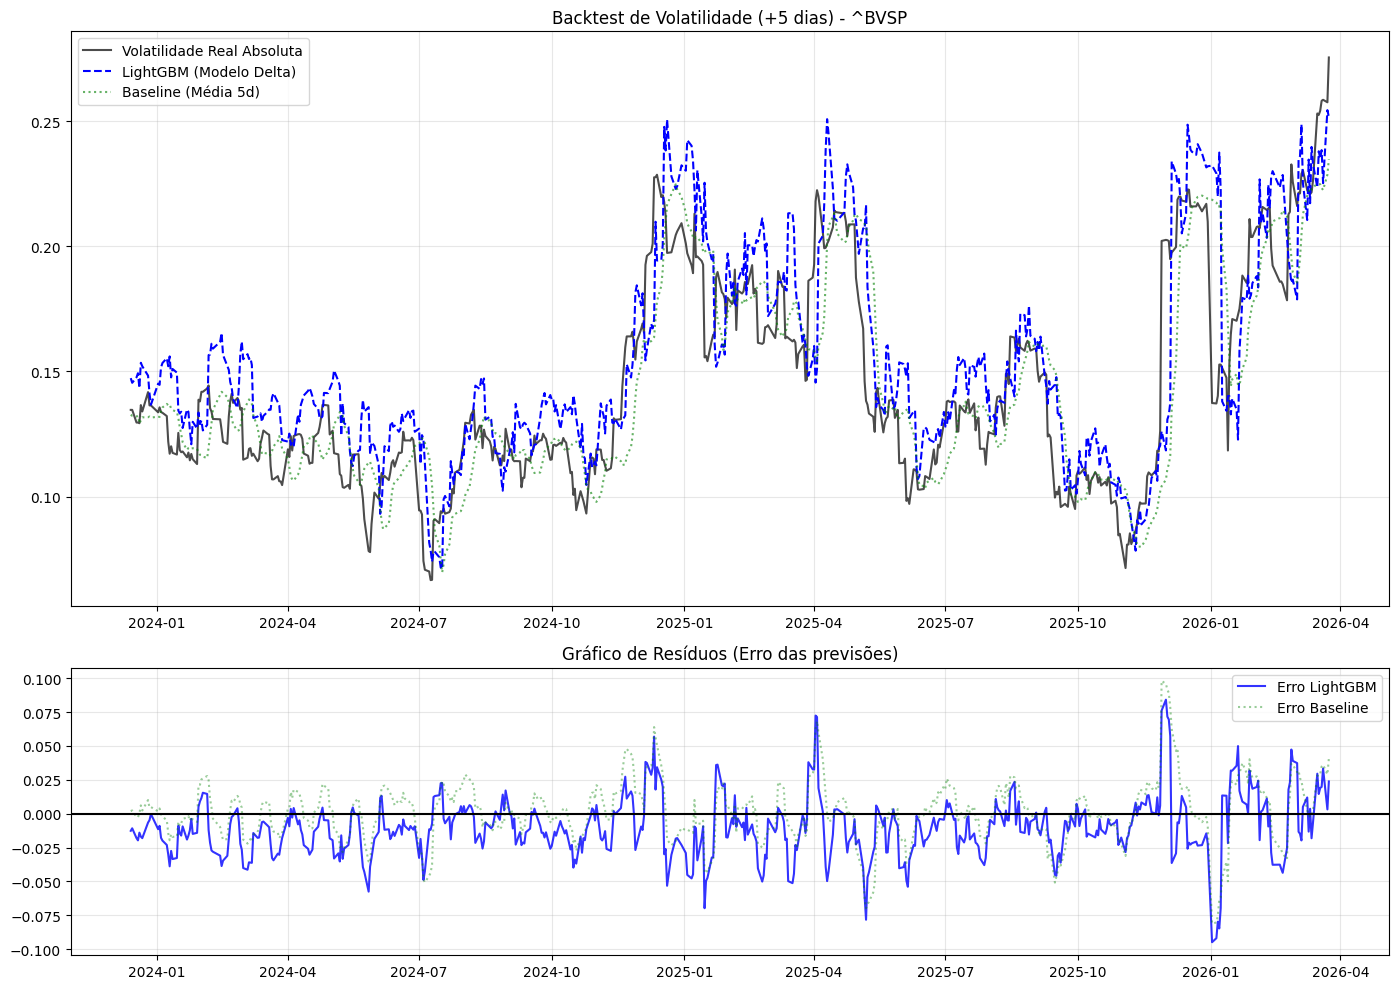

Modelo exportado com sucesso para 'lightgbm_model.joblib'!

=== TESTE ADF NAS JANELAS ROLANTES ===
Janelas testadas     : 42
Estacionárias        : 100.0% das janelas
Média dos p-values   : 0.0000
                 p_value  estacionario
data                                  
2025-03-20  2.268636e-29          True
2025-06-23  2.156308e-29          True
2025-09-18  1.011149e-29          True
2025-12-17  7.271727e-30          True
2026-03-24  1.186803e-29          True

=== WALK-FORWARD EXPANSIVO ===
  Treino até 2015-10-23 | Val: 2015-10-26 → 2016-01-29
  Treino até 2016-01-29 | Val: 2016-02-01 → 2016-05-03
  Treino até 2016-05-03 | Val: 2016-05-04 → 2016-08-01
  Treino até 2016-08-01 | Val: 2016-08-02 → 2016-10-31
  Treino até 2016-10-31 | Val: 2016-11-01 → 2017-02-01
  Treino até 2017-02-01 | Val: 2017-02-02 → 2017-05-08
  Treino até 2017-05-08 | Val: 2017-05-09 → 2017-08-04
  Treino até 2017-08-04 | Val: 2017-08-07 → 2017-11-06
  Treino até 2017-11-06 | Val: 2017-11-07 → 2018-02-08
  T

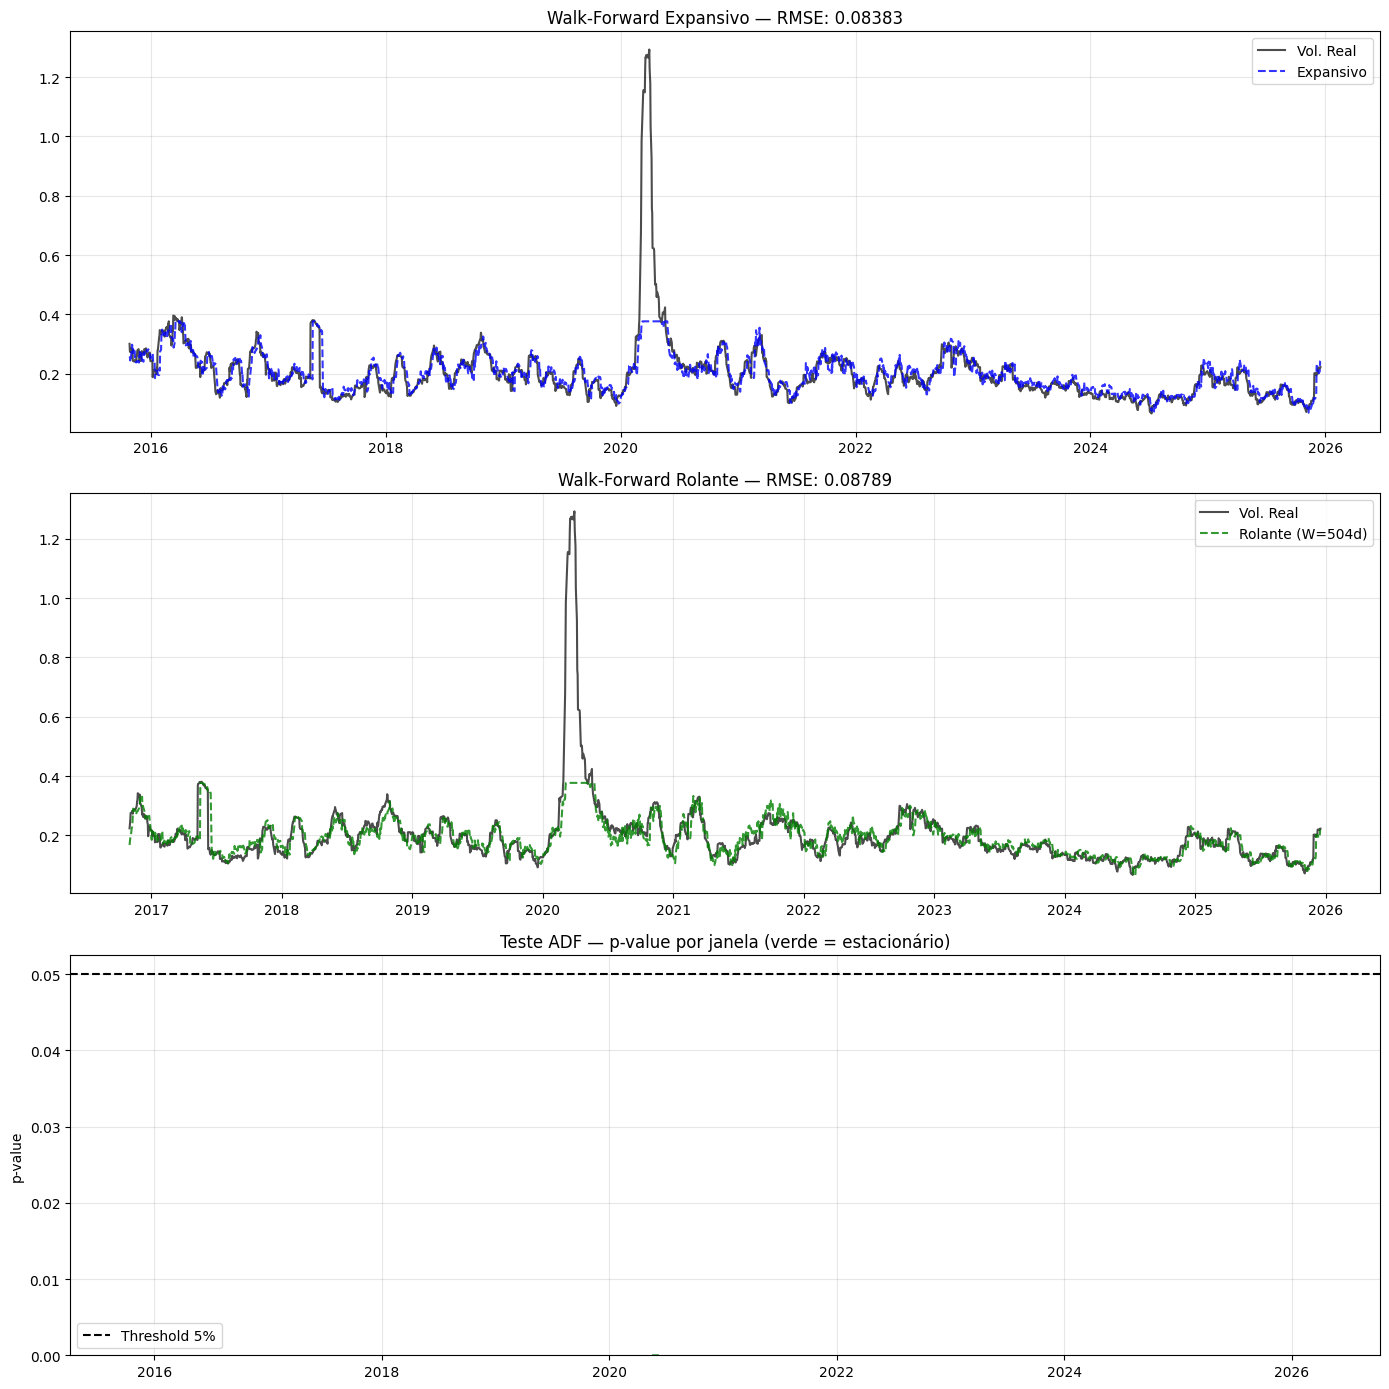

In [9]:
# -*- coding: utf-8 -*-
"""TesteBaseline.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1hH0zWyj5C_SID8uillwaJ6luyQ5ol97t
"""

!pip install optuna
!pip install statsmodels

import yfinance as yf
import pandas as pd
import numpy as np
import lightgbm as lgb
import optuna
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
import joblib
from statsmodels.tsa.stattools import adfuller # Função do teste ADF

warnings.filterwarnings('ignore')

# 1. CONFIGURAÇÕES INICIAIS
TICKER = '^BVSP'
WINDOW = 21 # Janela de volatilidade
START_DATE = '2014-09-17'

#Data de "Hoje"
#END_DATE = datetime.today().strftime('%Y-%m-%d')
#Data teste
END_DATE = '2026-04-01'

def fetch_and_prepare_data(ticker):
    print(f"Baixando dados reais de {ticker} até {END_DATE}...")
    df = yf.download(ticker, start=START_DATE, end=END_DATE, auto_adjust=True, progress=False)

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    # 1. Retornos e Target Absoluto
    df['returns'] = np.log(df['Close'] / df['Close'].shift(1))
    df['target_vol'] = df['returns'].rolling(window=WINDOW).std() * np.sqrt(252)
    df['target_vol_future'] = df['target_vol'].shift(-5)

    # ====================================================================
    # A SOLUÇÃO: CRIANDO O DELTA AQUI!
    # O modelo vai aprender a prever a VARIAÇÃO, não o valor absoluto.
    # ====================================================================
    df['target_delta'] = df['target_vol_future'] - df['target_vol']

    # 2. Features Base
    df['lag_vol_1'] = df['target_vol'].shift(1)
    df['lag_vol_5'] = df['target_vol'].shift(5)
    df['returns_sq'] = df['returns']**2
    df['ema_returns'] = df['returns'].ewm(span=WINDOW).mean()

    rs = (1.0 / (4.0 * np.log(2.0))) * (np.log(df['High'] / df['Low']) ** 2)
    df['parkinson_vol'] = np.sqrt(rs.rolling(window=WINDOW).mean()) * np.sqrt(252)

    df['vol_media_5d'] = df['target_vol'].rolling(window=5).mean()
    df['vol_media_21d'] = df['target_vol'].rolling(window=21).mean()
    df['vol_media_63d'] = df['target_vol'].rolling(window=63).mean()

    df['skew_21'] = df['returns'].rolling(window=WINDOW).skew()
    df['kurt_21'] = df['returns'].rolling(window=WINDOW).kurt()

    # 3. Macroeconomia
    print("Baixando dados macro (IBOV e Dólar)...")
    macro_data = yf.download(['^BVSP', 'BRL=X'], start=START_DATE, end=END_DATE, progress=False)['Close']

    df['retorno_ibov'] = np.log(macro_data['^BVSP'] / macro_data['^BVSP'].shift(1))
    df['retorno_dolar'] = np.log(macro_data['BRL=X'] / macro_data['BRL=X'].shift(1))

    df['retorno_ibov'] = df['retorno_ibov'].fillna(0)
    df['retorno_dolar'] = df['retorno_dolar'].fillna(0)

    # 4. Indicadores Técnicos
    delta = df['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    df['rsi_14'] = 100 - (100 / (1 + (gain / loss)))

    bb_media = df['Close'].rolling(window=20).mean()
    bb_std = df['Close'].rolling(window=20).std()
    df['bb_distancia_topo'] = (bb_media + (2 * bb_std)) - df['Close']

    # Limpeza final (Agora com o target_delta existindo!)
    features_obrigatorias = ['lag_vol_1', 'parkinson_vol', 'kurt_21', 'retorno_ibov', 'rsi_14', 'bb_distancia_topo']
    df_features_prontas = df.dropna(subset=features_obrigatorias)

    return df_features_prontas

# 2. PREPARAÇÃO DE TREINO, TESTE E O "FUTURO DESCONHECIDO"

df_model = fetch_and_prepare_data(TICKER)

features = [
    'target_vol', # <--- AQUI ESTAVA O SEU MAIOR ERRO. O modelo precisa saber o hoje!
    'lag_vol_1', 'lag_vol_5', 'returns_sq', 'ema_returns',
    'parkinson_vol', 'vol_media_5d', 'vol_media_21d',
    'vol_media_63d', 'skew_21', 'kurt_21',
    'retorno_ibov', 'retorno_dolar', 'rsi_14', 'bb_distancia_topo'
]

# Separamos os dados em duas caixas:
# 1. Histórico: Onde temos o target do futuro preenchido (dá pra treinar/testar)
df_historico = df_model.dropna(subset=['target_vol_future'])

# 2. O Futuro Real: Os últimos 5 dias do dataset. Eles têm features, mas o
# 'target_vol_future' é NaN (porque o futuro ainda não aconteceu!).
df_futuro_real = df_model[df_model['target_vol_future'].isna()]

X = df_historico[features]
y = df_historico['target_delta']

# Divisão de 80% Treino / 20% Teste (sem embaralhar, respeitando a linha do tempo)
split_idx = int(len(df_historico) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"\nDados separados! Treino: {len(X_train)} dias | Teste: {len(X_test)} dias.")

# 3. OTIMIZAÇÃO COM OPTUNA E TIMESERIESSPLIT
def objective(trial):
    param = {
        'objective': 'regression',
        'metric': 'rmse',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 2, 64),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.4, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.4, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
    }

    tscv = TimeSeriesSplit(n_splits=5)
    errors = []

    for train_index, val_index in tscv.split(X_train):
        X_t, X_v = X_train.iloc[train_index], X_train.iloc[val_index]
        y_t, y_v = y_train.iloc[train_index], y_train.iloc[val_index]

        gbm = lgb.LGBMRegressor(**param)

        # O early_stopping avisa a hora certa de parar para não decorar os dados (Overfitting)
        callbacks = [lgb.early_stopping(stopping_rounds=30, verbose=False)]
        gbm.fit(X_t, y_t, eval_set=[(X_v, y_v)], callbacks=callbacks)

        preds = gbm.predict(X_v)
        errors.append(np.sqrt(mean_squared_error(y_v, preds)))

    return np.mean(errors)

# Executa a busca pelos melhores parâmetros (reduzido para 20 pra rodar rápido ao vivo)
optuna.logging.set_verbosity(optuna.logging.WARNING)
print("Otimizando hiperparâmetros do modelo (Isso leva alguns segundos)...")
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20)

# 4. TREINO FINAL E TRAVAS DE SEGURANÇA (O Clip)

best_params = study.best_params
model = lgb.LGBMRegressor(**best_params)
model.fit(X_train, y_train)

# CORREÇÃO 1: O limite máximo deve ser calculado sobre os valores ABSOLUTOS do histórico
limite_maximo_vol = np.percentile(df_historico['target_vol_future'], 97)

# 5. AVALIAÇÃO DO MODELO NO PASSADO RECENTE (O Backtest)

# O modelo cospe as variações (deltas)
pred_deltas = model.predict(X_test)

# A previsão final é a vol atual + o delta previsto
test_preds = X_test['target_vol'].values + pred_deltas

# Trava as previsões dentro de limites realistas (1% no mínimo, e o novo teto corrigido)
test_preds = np.clip(test_preds, 0.01, limite_maximo_vol)

# CORREÇÃO 2: Recriando o valor absoluto real do teste para o RMSE e para o Gráfico
y_test_absoluto = X_test['target_vol'].values + y_test.values

final_rmse = np.sqrt(mean_squared_error(y_test_absoluto, test_preds))
final_mape = mean_absolute_percentage_error(y_test_absoluto, test_preds)

# Baseline: Prever que o futuro será igual à média dos últimos 5 dias
baseline_preds = X_test['vol_media_5d'].values
baseline_rmse = np.sqrt(mean_squared_error(y_test_absoluto, baseline_preds))

print(f"\n===============================================")
print(f"RESULTADO DO BACKTEST (Set de Teste)")
print(f"===============================================")
print(f"  RMSE LightGBM : {final_rmse:.5f} (Previsão via Delta)")
print(f"  RMSE Baseline : {baseline_rmse:.5f} (Média Móvel)")
print(f"  MAPE          : {final_mape*100:.2f}%")

!pip install arch

# ==============================================================================
# BENCHMARKING E VALIDAÇÃO RELATIVA (PROVANDO O ALPHA DO LIGHTGBM)
# ==============================================================================
import warnings
from arch import arch_model
from sklearn.metrics import mean_absolute_error
warnings.filterwarnings('ignore')

print("\n===============================================")
print("INICIANDO COMPETIÇÃO DE MODELOS (BENCHMARKING)")
print("===============================================")

# ---------------------------------------------------------
# 1. O CONCORRENTE 1: MODELO NAIVE (RANDOM WALK)
# Regra: A previsão de T+5 é exatamente a volatilidade observada hoje (em T).
# ---------------------------------------------------------
preds_naive = X_test['target_vol'].values
rmse_naive = np.sqrt(mean_squared_error(y_test_absoluto, preds_naive))
mae_naive = mean_absolute_error(y_test_absoluto, preds_naive)

# ---------------------------------------------------------
# 2. O CONCORRENTE 2: GARCH(1,1) (O CLÁSSICO)
# ---------------------------------------------------------
print("Treinando o modelo GARCH(1,1) (Isso pode levar alguns segundos)...")

retornos_totais = df_model['returns'] * 100
fim_treino = X_train.index[-1]
inicio_teste = X_test.index[0]

modelo_garch = arch_model(retornos_totais, vol='Garch', p=1, q=1, rescale=False)
resultado_garch = modelo_garch.fit(last_obs=fim_treino, disp='off')

# O SEGREDO AQUI: Usar o forecast para projetar o futuro (out-of-sample)
# Pedimos um horizonte de 5 dias para bater com o T+5 do LightGBM
previsoes = resultado_garch.forecast(start=inicio_teste, horizon=5)

# Pegamos a coluna 'h.5' (horizonte de 5 dias) e alinhamos com as datas do teste
garch_var_teste = previsoes.variance['h.5'].loc[X_test.index]

# Transformamos variância em volatilidade, anualizamos e voltamos a escala normal
preds_garch = (np.sqrt(garch_var_teste) * np.sqrt(252)) / 100
preds_garch = preds_garch.values

# Trava de segurança: Se o GARCH falhar na matemática no último dia e gerar um NaN isolado,
# copiamos o valor do dia anterior (Forward Fill) para não quebrar o script.
if np.isnan(preds_garch).any():
    preds_garch = pd.Series(preds_garch).ffill().bfill().values

rmse_garch = np.sqrt(mean_squared_error(y_test_absoluto, preds_garch))
mae_garch = mean_absolute_error(y_test_absoluto, preds_garch)


# ---------------------------------------------------------
# 3. CALCULANDO O ALPHA (GANHO RELATIVO)
# ---------------------------------------------------------
# Alpha = O quanto o LightGBM erra a menos que o Naive e o GARCH.
# Exemplo: Se o erro reduziu de 0.10 para 0.08, temos 20% de ganho.
ganho_rmse_vs_naive = ((rmse_naive - final_rmse) / rmse_naive) * 100
ganho_rmse_vs_garch = ((rmse_garch - final_rmse) / rmse_garch) * 100

print(f"\n[ RESULTADOS GERAIS DO BACKTEST ]")
print(f"RMSE Naive (Zé da Esquina) : {rmse_naive:.5f}")
print(f"RMSE GARCH(1,1) (Clássico) : {rmse_garch:.5f}")
print(f"RMSE LightGBM (Seu Modelo) : {final_rmse:.5f}")
print(f"-> Alpha do LightGBM sobre o Naive: +{ganho_rmse_vs_naive:.1f}% de precisão")
print(f"-> Alpha do LightGBM sobre o GARCH: +{ganho_rmse_vs_garch:.1f}% de precisão")

# ---------------------------------------------------------
# 4. O TESTE DE FOGO: BEAR MARKET (JANELAS DE ESTRESSE)
# ---------------------------------------------------------
# Definindo Bear Market: Dias em que o retorno do IBOV foi muito negativo (pânico no mercado)
# ou a volatilidade do BTC estava no quartil mais alto (extremo risco).
limite_vol_alta = np.percentile(y_test_absoluto, 75)
mascara_bear_market = (X_test['retorno_ibov'] < -0.015) | (X_test['target_vol'] > limite_vol_alta)

# Filtrando os dados apenas para esses dias tensos
y_test_bear = y_test_absoluto[mascara_bear_market]
preds_lgbm_bear = test_preds[mascara_bear_market]
preds_naive_bear = preds_naive[mascara_bear_market]
preds_garch_bear = preds_garch[mascara_bear_market]

rmse_lgbm_bear = np.sqrt(mean_squared_error(y_test_bear, preds_lgbm_bear))
rmse_naive_bear = np.sqrt(mean_squared_error(y_test_bear, preds_naive_bear))
rmse_garch_bear = np.sqrt(mean_squared_error(y_test_bear, preds_garch_bear))

ganho_bear_vs_naive = ((rmse_naive_bear - rmse_lgbm_bear) / rmse_naive_bear) * 100
ganho_bear_vs_garch = ((rmse_garch_bear - rmse_lgbm_bear) / rmse_garch_bear) * 100

print(f"\n[ 🚨 TESTE DE ESTRESSE: BEAR MARKET 🚨 ]")
print(f"Dias de pânico analisados: {len(y_test_bear)} dias")
print(f"RMSE Naive (Bear Market)   : {rmse_naive_bear:.5f}")
print(f"RMSE GARCH (Bear Market)   : {rmse_garch_bear:.5f}")
print(f"RMSE LightGBM (Bear Market): {rmse_lgbm_bear:.5f}")
print(f"-> Sobrevivência do LightGBM vs Naive: Melhorou +{ganho_bear_vs_naive:.1f}%")
print(f"-> Sobrevivência do LightGBM vs GARCH: Melhorou +{ganho_bear_vs_garch:.1f}%")

# 6. A PREVISÃO DO FUTURO
ultima_linha = df_futuro_real.tail(1)
data_base = ultima_linha.index[0].strftime('%Y-%m-%d')
volatilidade_hoje = ultima_linha['target_vol'].values[0]

delta_futuro = model.predict(ultima_linha[features])[0]
previsao_futura = np.clip((volatilidade_hoje + delta_futuro), 0.01, limite_maximo_vol)

print(f"\n===============================================")
print(f"A PREVISÃO DO FUTURO")
print(f"===============================================")
print(f"  Data Base                 : {data_base}")
print(f"  Volatilidade Atual        : {volatilidade_hoje*100:.1f}% a.a.")
print(f"  Previsão para daqui 5 dias: {previsao_futura*100:.1f}% a.a.")
print(f"===============================================\n")

# 7. GRÁFICOS: PREVISÃO E RESÍDUOS
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2, 1]})

# Gráfico Superior (Agora plotando y_test_absoluto!)
ax1.plot(X_test.index, y_test_absoluto, label='Volatilidade Real Absoluta', color='black', alpha=0.7)
ax1.plot(X_test.index, test_preds, label='LightGBM (Modelo Delta)', color='blue', linestyle='--')
ax1.plot(X_test.index, baseline_preds, label='Baseline (Média 5d)', color='green', linestyle=':', alpha=0.6)
ax1.set_title(f'Backtest de Volatilidade (+5 dias) - {TICKER}')
ax1.legend()
ax1.grid(alpha=0.3)

# Gráfico Inferior
residuos_lgbm = y_test_absoluto - test_preds
residuos_baseline = y_test_absoluto - baseline_preds

ax2.plot(X_test.index, residuos_lgbm, label='Erro LightGBM', color='blue', alpha=0.8)
ax2.plot(X_test.index, residuos_baseline, label='Erro Baseline', color='green', alpha=0.4, linestyle=':')
ax2.axhline(0, color='black', linestyle='-', linewidth=1.5)
ax2.set_title('Gráfico de Resíduos (Erro das previsões)')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 8. Exportação do modelo
joblib.dump(model, 'lightgbm_model.joblib')
print("Modelo exportado com sucesso para 'lightgbm_model.joblib'!")

# TESTE DE ESTACIONARIEDADE (ADF) NAS JANELAS ROLANTES
# Objetivo: verificar se os retornos log são estacionários ao longo do tempo.
# Uma série estacionária tem média e variância constantes — pré-requisito para
# que o modelo aprenda padrões confiáveis.

def testar_adf_em_janelas(retornos, janela=252, passo=63):
    """
    Aplica o teste ADF periodicamente em janelas rolantes.

    Parâmetros:
    - retornos: pd.Series com os retornos log diários
    - janela: tamanho da janela (252 = ~1 ano de pregões)
    - passo: de quantos em quantos dias re-testar (63 = ~1 trimestre)

    Retorna: DataFrame com data, p-value e resultado (estacionário ou não)
    """
    resultados = []

    for i in range(janela, len(retornos), passo):
        janela_atual = retornos.iloc[i - janela : i]
        data_fim = retornos.index[i - 1]

        # O teste ADF retorna: (estatística, p-value, lags, nobs, valores_criticos, ...)
        stat, pvalue, _, _, valores_criticos, _ = adfuller(janela_atual.dropna())

        resultados.append({
            'data': data_fim,
            'adf_statistic': stat,
            'p_value': pvalue,
            'critico_5pct': valores_criticos['5%'],
            # Se p < 0.05 → rejeita hipótese nula (série TEM raiz unitária) → é estacionária
            'estacionario': pvalue < 0.05
        })

    return pd.DataFrame(resultados).set_index('data')

# Roda o teste nos retornos log do BTC
df_adf = testar_adf_em_janelas(df_model['returns'])

# Resumo dos resultados
pct_estacionario = df_adf['estacionario'].mean() * 100
print(f"\n=== TESTE ADF NAS JANELAS ROLANTES ===")
print(f"Janelas testadas     : {len(df_adf)}")
print(f"Estacionárias        : {pct_estacionario:.1f}% das janelas")
print(f"Média dos p-values   : {df_adf['p_value'].mean():.4f}")
print(df_adf[['p_value', 'estacionario']].tail(5).to_string())

# WALK-FORWARD COM JANELA EXPANSIVA
# A cada passo, o modelo é treinado com TUDO que veio antes
# e prevê o próximo bloco de dias. Simula uso real no tempo.

def walk_forward_expansivo(X, y, step_size=63, min_train=252):
    """
    step_size: quantos dias o modelo prevê por vez (63 = ~1 trimestre)
    min_train : mínimo de dias para o primeiro treino (252 = ~1 ano)
    """
    previsoes = []
    reais = []
    datas = []

    # Começa com min_train dias e vai expandindo
    for start in range(min_train, len(X) - step_size, step_size):
        # Janela expansiva: sempre começa do início (índice 0)
        X_treino = X.iloc[:start]
        y_treino = y.iloc[:start]

        # Previsão no próximo bloco
        X_val = X.iloc[start : start + step_size]
        y_val = y.iloc[start : start + step_size]

        # Treina com os melhores parâmetros encontrados pelo Optuna
        modelo_wf = lgb.LGBMRegressor(**best_params, verbosity=-1)
        modelo_wf.fit(X_treino, y_treino)

        # Reconstrói o valor absoluto: vol_atual + delta previsto
        pred_deltas = modelo_wf.predict(X_val)
        preds_abs = X_val['target_vol'].values + pred_deltas
        preds_abs = np.clip(preds_abs, 0.01, limite_maximo_vol)

        reais_abs = X_val['target_vol'].values + y_val.values

        previsoes.extend(preds_abs)
        reais.extend(reais_abs)
        datas.extend(X_val.index.tolist())

        print(f"  Treino até {X_treino.index[-1].date()} | "
              f"Val: {X_val.index[0].date()} → {X_val.index[-1].date()}")

    return pd.Series(previsoes, index=datas), pd.Series(reais, index=datas)

print("\n=== WALK-FORWARD EXPANSIVO ===")
preds_exp, reais_exp = walk_forward_expansivo(X, y)

rmse_exp = np.sqrt(mean_squared_error(reais_exp, preds_exp))
mape_exp = mean_absolute_percentage_error(reais_exp, preds_exp)
print(f"\n  RMSE Expansivo : {rmse_exp:.5f}")
print(f"  MAPE Expansivo : {mape_exp*100:.2f}%")

# WALK-FORWARD COM JANELA ROLANTE
# A cada passo, o modelo é treinado apenas nos ÚLTIMOS W dias.
# Dados muito antigos são descartados — o modelo foca no regime atual.

def walk_forward_rolante(X, y, window_size=504, step_size=63):
    """
    window_size: tamanho fixo da janela de treino em dias (504 = ~2 anos)
    step_size  : bloco de previsão a cada passo
    """
    previsoes = []
    reais = []
    datas = []

    for end in range(window_size, len(X) - step_size, step_size):
        # Janela rolante: só os últimos w dias
        start = end - window_size
        X_treino = X.iloc[start:end]
        y_treino = y.iloc[start:end]

        X_val = X.iloc[end : end + step_size]
        y_val = y.iloc[end : end + step_size]

        modelo_wf = lgb.LGBMRegressor(**best_params, verbosity=-1)
        modelo_wf.fit(X_treino, y_treino)

        pred_deltas = modelo_wf.predict(X_val)
        preds_abs = X_val['target_vol'].values + pred_deltas
        preds_abs = np.clip(preds_abs, 0.01, limite_maximo_vol)

        reais_abs = X_val['target_vol'].values + y_val.values

        previsoes.extend(preds_abs)
        reais.extend(reais_abs)
        datas.extend(X_val.index.tolist())

        print(f"  Treino: {X_treino.index[0].date()} → {X_treino.index[-1].date()} | "
              f"Val: {X_val.index[-1].date()}")

    return pd.Series(previsoes, index=datas), pd.Series(reais, index=datas)

print("\n=== WALK-FORWARD ROLANTE ===")
preds_rol, reais_rol = walk_forward_rolante(X, y)

rmse_rol = np.sqrt(mean_squared_error(reais_rol, preds_rol))
mape_rol = mean_absolute_percentage_error(reais_rol, preds_rol)
print(f"\n  RMSE Rolante : {rmse_rol:.5f}")
print(f"  MAPE Rolante : {mape_rol*100:.2f}%")

# COMPARAÇÃO E GRÁFICOS

# Período em comum entre as duas abordagens para comparação justa
idx_comum = preds_exp.index.intersection(preds_rol.index)

print("\n==============================================")
print("COMPARAÇÃO DAS ESTRATÉGIAS DE JANELA")
print("==============================================")
print(f"  RMSE Baseline (estático 80/20) : {final_rmse:.5f}")
print(f"  RMSE Walk-Forward Expansivo    : {rmse_exp:.5f}")
print(f"  RMSE Walk-Forward Rolante      : {rmse_rol:.5f}")
print("----------------------------------------------")
melhor = min([
    ("Estático", final_rmse),
    ("Expansivo", rmse_exp),
    ("Rolante", rmse_rol)
], key=lambda x: x[1])
print(f"  Melhor: {melhor[0]} com RMSE = {melhor[1]:.5f}")
print("==============================================")

# --- Gráficos ---
fig, axes = plt.subplots(3, 1, figsize=(14, 14))

# Gráfico 1: Walk-Forward Expansivo
axes[0].plot(reais_exp.index, reais_exp.values, label='Vol. Real', color='black', alpha=0.7)
axes[0].plot(preds_exp.index, preds_exp.values, label='Expansivo', color='blue',
             linestyle='--', alpha=0.8)
axes[0].set_title(f'Walk-Forward Expansivo — RMSE: {rmse_exp:.5f}')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Gráfico 2: Walk-Forward Rolante
axes[1].plot(reais_rol.index, reais_rol.values, label='Vol. Real', color='black', alpha=0.7)
axes[1].plot(preds_rol.index, preds_rol.values, label='Rolante (W=504d)', color='green',
             linestyle='--', alpha=0.8)
axes[1].set_title(f'Walk-Forward Rolante — RMSE: {rmse_rol:.5f}')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Gráfico 3: ADF ao longo do tempo
cor_adf = ['green' if v else 'red' for v in df_adf['estacionario']]
axes[2].bar(df_adf.index, df_adf['p_value'], color=cor_adf, alpha=0.6, width=20)
axes[2].axhline(0.05, color='black', linestyle='--', linewidth=1.5, label='Threshold 5%')
axes[2].set_title('Teste ADF — p-value por janela (verde = estacionário)')
axes[2].set_ylabel('p-value')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()